In [1]:
# ============================================================
# DESAFIO FINAL - ANÁLISE FINANCEIRA
# ClearBank
#
# Rodrigo Garcia Abegão
# ============================================================
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00

def moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X",".")


def validar_transacao(linha):

  try:
      id_transacao = int(linha["id"])
  except ValueError:
      return None

  cliente = linha["cliente_id"].strip()

  if cliente == "":
      return None

  try:
      data = datetime.strptime(linha["data"], "%Y-%m-%d")
  except ValueError:
      return None

  tipo = linha["tipo"].lower()

  if tipo not in ["credito", "debito"]:
      return None

  try:
      valor = float(linha["valor"])
  except ValueError:
      return None

  if valor <= 0:
      return None

  return {
      "id": id_transacao,
      "data": data,
      "cliente_id": cliente,
      "tipo": tipo,
      "valor": valor,
      "descricao": linha["descricao"],
      "categoria": linha["categoria"]
  }

def ler_transacoes(nome_arquivo):

  transacoes = []

  total = 0
  invalidas = 0

  try:

      with open(nome_arquivo,
                encoding="utf-8",
                newline="") as arquivo:

          leitor = csv.DictReader(arquivo)

          for linha in leitor:

              total += 1

              registro = validar_transacao(linha)

              if registro:

                  transacoes.append(registro)

              else:

                  invalidas += 1

  except FileNotFoundError:

      print("Arquivo não encontrado.")

      return [],0,0

  return transacoes,total,invalidas

def gerar_relatorio(transacoes):

  resumo = {}

  suspeitas = []

  for t in transacoes:

      mes = t["data"].strftime("%Y-%m")

      if mes not in resumo:

          resumo[mes] = {

              "quantidade":0,

              "total_credito":0,

              "total_debito":0,

              "saldo":0,

              "media":0,

              "maior":t["valor"],

              "menor":t["valor"],

              "soma":0

          }

      r = resumo[mes]

      r["quantidade"] += 1

      r["soma"] += t["valor"]

      if t["tipo"] == "credito":

          r["total_credito"] += t["valor"]

      else:

          r["total_debito"] += t["valor"]

      if t["valor"] > r["maior"]:

          r["maior"] = t["valor"]

      if t["valor"] < r["menor"]:

          r["menor"] = t["valor"]

      if t["valor"] > LIMITE_SUSPEITO:

          suspeitas.append(t)

  for mes in resumo:

      r = resumo[mes]

      r["saldo"] = r["total_credito"] - r["total_debito"]

      r["media"] = r["soma"]/r["quantidade"]

      del r["soma"]

  return resumo,suspeitas

def exibir_relatorio(resumo, suspeitas, validas, invalidas, transacoes):

  print("=" * 50)
  print("RELATÓRIO FINANCEIRO")
  print("=" * 50)

  data_inicial = min(t["data"] for t in transacoes)
  data_final = max(t["data"] for t in transacoes)

  print(f"\nPeríodo analisado: {data_inicial.strftime('%d/%m/%Y')} até {data_final.strftime('%d/%m/%Y')}")
  print(f"Transações válidas: {validas}")
  print(f"Transações inválidas: {invalidas}")

  print("\n===== RELATÓRIO MENSAL =====")

  for mes in sorted(resumo):

      r = resumo[mes]

      print(f"\nMês: {mes}")
      print(f"  Quantidade:      {r['quantidade']}")
      print(f"  Total Crédito:   {moeda(r['total_credito'])}")
      print(f"  Total Débito:    {moeda(r['total_debito'])}")
      print(f"  Saldo:           {moeda(r['saldo'])}")
      print(f"  Média:           {moeda(r['media'])}")
      print(f"  Maior valor:     {moeda(r['maior'])}")
      print(f"  Menor valor:     {moeda(r['menor'])}")

  print("\n===== TRANSAÇÕES SUSPEITAS =====")

  if len(suspeitas) == 0:
      print("Nenhuma transação suspeita encontrada.")
  else:

      for t in suspeitas:

          print(
              f"ID: {t['id']} | "
              f"Cliente: {t['cliente_id']} | "
              f"Data: {t['data'].strftime('%Y-%m-%d')} | "
              f"Valor: {moeda(t['valor'])}"
          )

def salvar_json(resumo, validas, invalidas):

  dados = {

      "gerado_em": datetime.now().strftime("%Y-%m-%d"),

      "total_transacoes_validas": validas,

      "total_transacoes_invalidas": invalidas,

      "resumo_mensal": resumo

  }

  with open(
      "relatorio.json",
      "w",
      encoding="utf-8"
  ) as arquivo:

      json.dump(
          dados,
          arquivo,
          indent=4,
          ensure_ascii=False
      )

  print("\nArquivo relatorio.json salvo com sucesso.")



In [2]:
transacoes, total, invalidas = ler_transacoes("transacoes.csv")

validas = len(transacoes)

print("===== LIMPEZA DOS DADOS =====")
print(f"Total de linhas lidas : {total}")
print(f"Linhas válidas        : {validas}")
print(f"Linhas inválidas      : {invalidas}")

resumo, suspeitas = gerar_relatorio(transacoes)

exibir_relatorio(
    resumo,
    suspeitas,
    validas,
    invalidas,
    transacoes
)

salvar_json(
    resumo,
    validas,
    invalidas
)

===== LIMPEZA DOS DADOS =====
Total de linhas lidas : 20
Linhas válidas        : 16
Linhas inválidas      : 4
RELATÓRIO FINANCEIRO

Período analisado: 05/01/2026 até 28/03/2026
Transações válidas: 16
Transações inválidas: 4

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Quantidade:      4
  Total Crédito:   R$ 16.000,00
  Total Débito:    R$ 430,50
  Saldo:           R$ 15.569,50
  Média:           R$ 4.107,62
  Maior valor:     R$ 12.500,00
  Menor valor:     R$ 180,50

Mês: 2026-02
  Quantidade:      5
  Total Crédito:   R$ 19.500,00
  Total Débito:    R$ 939,90
  Saldo:           R$ 18.560,10
  Média:           R$ 4.087,98
  Maior valor:     R$ 15.000,00
  Menor valor:     R$ 99,90

Mês: 2026-03
  Quantidade:      7
  Total Crédito:   R$ 18.100,00
  Total Débito:    R$ 1.115,00
  Saldo:           R$ 16.985,00
  Média:           R$ 2.745,00
  Maior valor:     R$ 5.200,00
  Menor valor:     R$ 75,00

===== TRANSAÇÕES SUSPEITAS =====
ID: 4 | Cliente: CLI003 | Data: 2026-01-22 | Valor: R

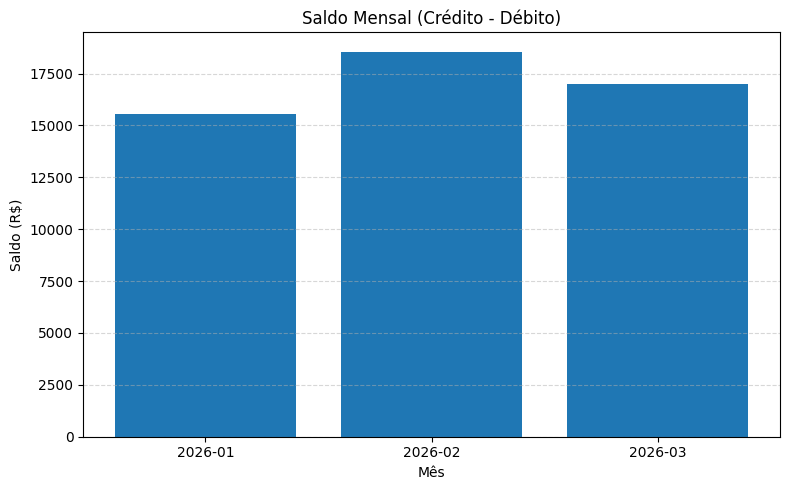

In [5]:
meses = sorted(resumo.keys())
saldos = [resumo[mes]["saldo"] for mes in meses]

plt.figure(figsize=(8,5))

plt.bar(meses, saldos)

plt.title("Saldo Mensal (Crédito - Débito)")
plt.xlabel("Mês")
plt.ylabel("Saldo (R$)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("grafico.png")   # nome exigido pelo desafio

plt.show()

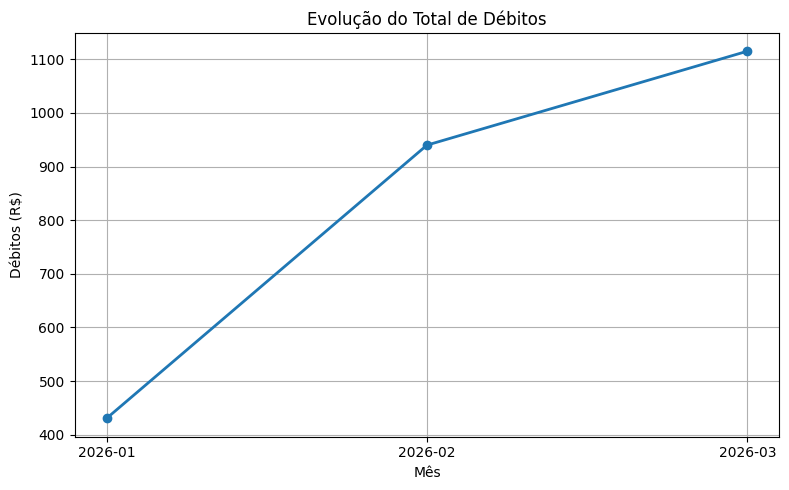

In [6]:
meses = sorted(resumo.keys())
debitos = [resumo[mes]["total_debito"] for mes in meses]

plt.figure(figsize=(8,5))

plt.plot(
    meses,
    debitos,
    marker="o",
    linewidth=2
)

plt.title("Evolução do Total de Débitos")
plt.xlabel("Mês")
plt.ylabel("Débitos (R$)")

plt.grid(True)

plt.tight_layout()

plt.savefig("grafico.png")

plt.show()

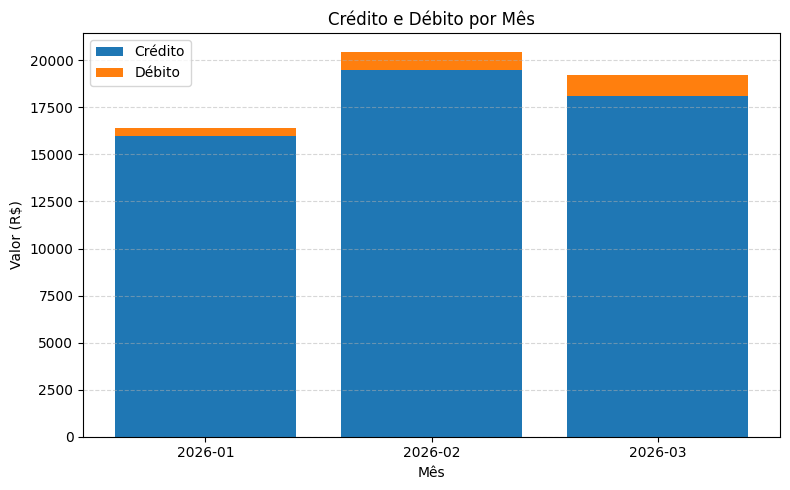

In [7]:
meses = sorted(resumo.keys())

creditos = [resumo[mes]["total_credito"] for mes in meses]
debitos = [resumo[mes]["total_debito"] for mes in meses]

plt.figure(figsize=(8,5))

plt.bar(
    meses,
    creditos,
    label="Crédito"
)

plt.bar(
    meses,
    debitos,
    bottom=creditos,
    label="Débito"
)

plt.title("Crédito e Débito por Mês")
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("grafico.png")

plt.show()